 # LLM Evaluation: Ollama vs External LLMs

 This notebook evaluates and compares the outputs of local (Ollama) vs external
 (DeepSeek, ChatGPT, etc.) LLMs for cybersecurity compliance report generation.

 **Fully-automated metrics computed:**
 1. JSON Parse Success Rate
 2. Schema Conformance Rate
 3. Finding Field Completeness
 4. Severity Distribution Validity
 5. Latency Analysis
 6. Token / Cost Estimation
 7. Cross-run Consistency (variance)
 8. Findings Origin (LLM vs Heuristic)
 9. Response Length Distribution

 ## Prerequisites
 Run `pip install pandas matplotlib seaborn scipy` if needed.

In [20]:
import json
import re
import os
import warnings
from pathlib import Path
from collections import Counter, defaultdict
from typing import Any, Dict, List, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid", palette="deep", font_scale=1.1)
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["figure.dpi"] = 120

print("Environment ready.")

Environment ready.


 ## 1. Load Evaluation Logs

 Reads the JSONL log file produced by the instrumented pipeline.
 Each line is one complete pipeline run with both LLM calls.

In [ ]:
EVAL_LOG_PATHS = [
    Path("../out/eval_logs/eval_log.jsonl"),       # relative from notebooks/
    Path("out/eval_logs/eval_log.jsonl"),           # from project root
    Path("/out/eval_logs/eval_log.jsonl"),           # Docker path
]

def find_eval_log() -> Optional[Path]:
    for p in EVAL_LOG_PATHS:
        if p.exists():
            print(f"Found eval log: {p.resolve()}")
            return p
    print("WARNING: No eval_log.jsonl found. Provide the path manually.")
    return None

def load_eval_logs(path: Path) -> List[Dict]:
    """Load all entries from a JSONL eval log file."""
    entries = []
    with open(path, "r", encoding="utf-8") as f:
        for i, line in enumerate(f, 1):
            line = line.strip()
            if not line:
                continue
            try:
                entries.append(json.loads(line))
            except json.JSONDecodeError as e:
                print(f"  Skipping line {i}: {e}")
    print(f"Loaded {len(entries)} evaluation log entries.")
    return entries

log_path = find_eval_log()
if log_path:
    raw_entries = load_eval_logs(log_path)
else:
    raw_entries = []
    print("No data loaded. Set log_path manually and re-run this cell.")

Found eval log: D:\User Files\ProgFiles\python\cybersec-compliance\out\eval_logs\eval_log.jsonl
Loaded 105 evaluation log entries.


In [ ]:
EVAL_LOG_PATHS = [
    Path("../out/eval_logs/eval_log.jsonl"),       # relative from notebooks/
    Path("out/eval_logs/eval_log.jsonl"),           # from project root
    Path("/out/eval_logs/eval_log.jsonl"),           # Docker path
]

def find_eval_log() -> Optional[Path]:
    for p in EVAL_LOG_PATHS:
        if p.exists():
            print(f"Found eval log: {p.resolve()}")
            return p
    print("WARNING: No eval_log.jsonl found. Provide the path manually.")
    return None

def load_eval_logs(path: Path) -> List[Dict]:
    """Load all entries from a JSONL eval log file."""
    entries = []
    with open(path, "r", encoding="utf-8") as f:
        for i, line in enumerate(f, 1):
            line = line.strip()
            if not line:
                continue
            try:
                entries.append(json.loads(line))
            except json.JSONDecodeError as e:
                print(f"  Skipping line {i}: {e}")
    print(f"Loaded {len(entries)} evaluation log entries.")
    return entries

log_path = find_eval_log()
if log_path:
    raw_entries = load_eval_logs(log_path)
else:
    raw_entries = []
    print("No data loaded. Set log_path manually and re-run this cell.")

Found eval log: D:\User Files\ProgFiles\python\cybersec-compliance\out\eval_logs\eval_log.jsonl
Loaded 105 evaluation log entries.


In [23]:
# Build a flat DataFrame for analysis
def flatten_entries(entries: List[Dict]) -> pd.DataFrame:
    """Flatten nested eval log entries into a tabular DataFrame."""
    rows = []
    for e in entries:
        cc = e.get("compliance_call") or {}
        ic = e.get("insight_call") or {}
        ie = ic.get("eval_metadata") or {}
        sv = ic.get("schema_validation") or {}

        rows.append({
            # Identifiers
            "run_id": e.get("run_id"),
            "timestamp": e.get("timestamp"),
            "provider": e.get("provider", "UNKNOWN"),
            "model": e.get("model", "unknown"),
            "period": e.get("period", "unknown"),
            "framework": e.get("framework", "NIS2"),

            # Compliance call
            "cc_latency": cc.get("latency_seconds"),
            "cc_prompt_chars": cc.get("prompt_length_chars"),
            "cc_response_chars": cc.get("response_length_chars"),
            "cc_prompt_tokens": cc.get("estimated_prompt_tokens"),
            "cc_response_tokens": cc.get("estimated_response_tokens"),
            "cc_success": cc.get("success"),

            # Insight call
            "ic_latency": ic.get("latency_seconds"),
            "ic_prompt_chars": ic.get("prompt_length_chars"),
            "ic_response_chars": ic.get("response_length_chars"),
            "ic_prompt_tokens": ic.get("estimated_prompt_tokens"),
            "ic_response_tokens": ic.get("estimated_response_tokens"),
            "ic_success": ic.get("success"),

            # Insight eval metadata
            "llm_latency": ie.get("llm_latency_seconds"),
            "llm_success": ie.get("llm_success"),
            "json_extract_success": ie.get("json_extract_success"),
            "json_parse_success": ie.get("json_parse_success"),
            "llm_findings_count": ie.get("llm_findings_count"),
            "heuristic_findings_added": ie.get("heuristic_findings_added"),
            "total_findings_count": ie.get("total_findings_count"),

            # Schema validation
            "schema_top_level_conformance": sv.get("top_level_conformance"),
            "schema_risk_level_valid": sv.get("risk_level_valid"),
            "schema_findings_count": sv.get("findings_count"),
            "schema_overall_conformance": sv.get("overall_conformance"),

            # Pipeline totals
            "total_pipeline_seconds": e.get("total_pipeline_seconds"),
            "report_length_chars": e.get("report_length_chars"),
        })

    df = pd.DataFrame(rows)
    if "timestamp" in df.columns:
        df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")
    return df


df = flatten_entries(raw_entries)
print(f"DataFrame shape: {df.shape}")
print(f"\nProviders: {df['provider'].value_counts().to_dict()}")
print(f"Models:    {df['model'].value_counts().to_dict()}")
print(f"Periods:   {df['period'].nunique()} unique")
df.head()

DataFrame shape: (105, 31)

Providers: {'EXTERNAL': 70, 'LOCAL': 35}
Models:    {'Qwen/Qwen3-32B-TEE': 35, 'gpt-5.4-nano': 35, 'llama3.1:8b': 35}
Periods:   7 unique


,run_id,timestamp,provider,model,period,framework,cc_latency,cc_prompt_chars,cc_response_chars,cc_prompt_tokens,...,json_parse_success,llm_findings_count,heuristic_findings_added,total_findings_count,schema_top_level_conformance,schema_risk_level_valid,schema_findings_count,schema_overall_conformance,total_pipeline_seconds,report_length_chars
0,b9425184-64fb-4f63-9ff4-c787a2ed7d72,2026-04-20 13:23:15.587433+00:00,EXTERNAL,Qwen/Qwen3-32B-TEE,Unknown period,NIS2,30.693,5363,3323,1340,...,True,3,1,4,1.0,True,3.0,1.0,62.124,8109
1,ff3a891f-998d-4f56-9647-a5aa2d45f6bd,2026-04-20 13:24:17.742133+00:00,EXTERNAL,Qwen/Qwen3-32B-TEE,2019-11-07T00:00:00 (window=90d),NIS2,20.923,5575,2343,1393,...,True,3,2,5,1.0,True,3.0,1.0,61.566,7080
2,0de09eb2-da04-48e3-9974-11bc8b56a1de,2026-04-20 13:25:19.339994+00:00,EXTERNAL,Qwen/Qwen3-32B-TEE,2020-02-05T00:00:00 (window=90d),NIS2,26.442,5600,2994,1400,...,True,3,2,5,1.0,True,3.0,1.0,72.201,7749
3,432d5453-c6fb-42fc-a7fa-69791b1cd0f0,2026-04-20 13:26:31.565337+00:00,EXTERNAL,Qwen/Qwen3-32B-TEE,2020-05-05T00:00:00 (window=90d),NIS2,23.159,5603,3485,1400,...,True,3,2,5,1.0,True,3.0,1.0,64.784,8347
4,08340df6-355b-44b4-8847-c177e9848ff1,2026-04-20 13:27:36.371328+00:00,EXTERNAL,Qwen/Qwen3-32B-TEE,2020-08-03T00:00:00 (window=90d),NIS2,16.802,5603,2199,1400,...,True,3,2,5,1.0,True,3.0,1.0,66.547,7081


## 2. JSON Parse Success Rate

 Does the LLM produce valid JSON for the insight generation call?
 This is the most fundamental structural metric: if JSON fails, the
 entire insight pipeline falls back to error/heuristic mode.

In [24]:
def compute_json_parse_rates(df: pd.DataFrame) -> pd.DataFrame:
    """Compute JSON extraction and parse success rates by provider/model."""
    group = df.groupby(["provider", "model"]).agg(
        total_runs=("run_id", "count"),
        json_extract_success=("json_extract_success", lambda x: x.sum()),
        json_parse_success=("json_parse_success", lambda x: x.sum()),
        llm_success=("llm_success", lambda x: x.sum()),
    ).reset_index()

    group["extract_rate"] = (group["json_extract_success"] / group["total_runs"] * 100).round(1)
    group["parse_rate"] = (group["json_parse_success"] / group["total_runs"] * 100).round(1)
    group["llm_call_success_rate"] = (group["llm_success"] / group["total_runs"] * 100).round(1)
    return group

json_rates = compute_json_parse_rates(df)
print("=== JSON Parse Success Rates ===")
display(json_rates[["provider", "model", "total_runs", "llm_call_success_rate",
                      "extract_rate", "parse_rate"]])

=== JSON Parse Success Rates ===


,provider,model,total_runs,llm_call_success_rate,extract_rate,parse_rate
0,EXTERNAL,Qwen/Qwen3-32B-TEE,35,100.0,100.0,100.0
1,EXTERNAL,gpt-5.4-nano,35,100.0,100.0,100.0
2,LOCAL,llama3.1:8b,35,100.0,100.0,91.4


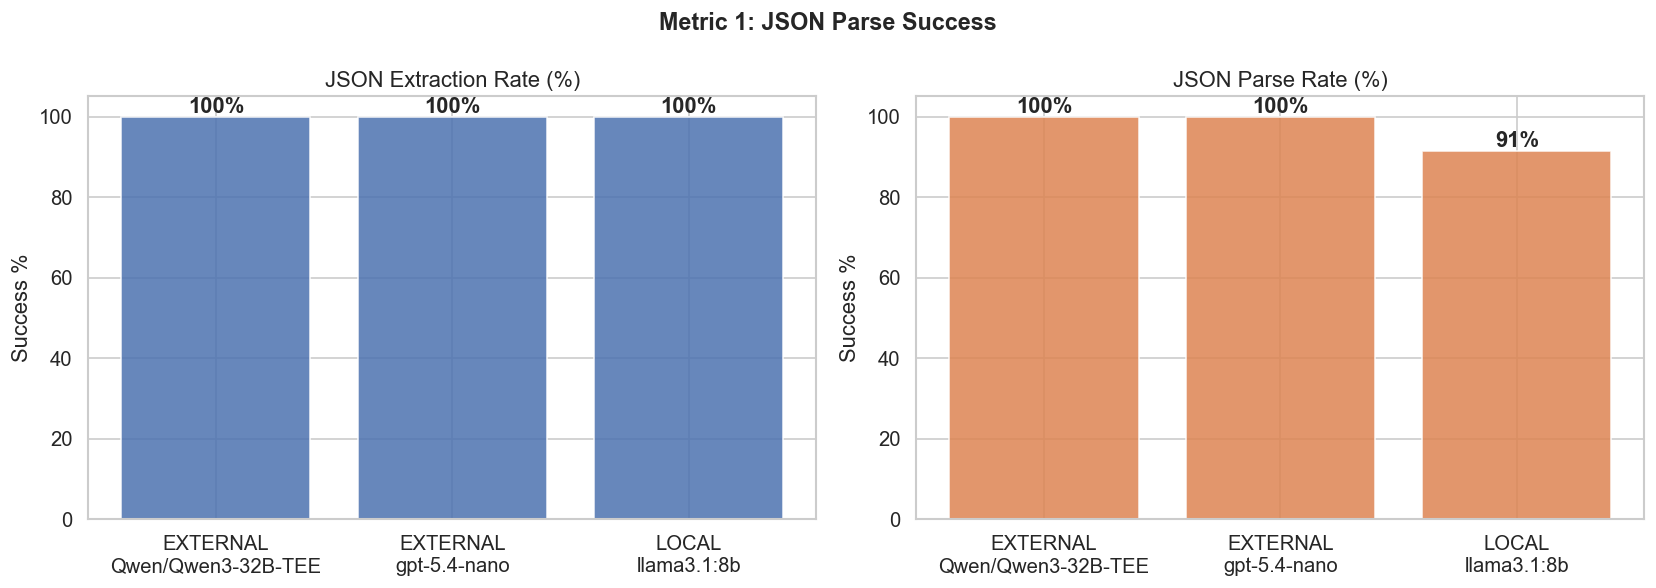

In [25]:
# Visualization
if len(json_rates) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    labels = json_rates["provider"] + "\n" + json_rates["model"]

    axes[0].bar(labels, json_rates["extract_rate"], color=sns.color_palette("deep")[0], alpha=0.85)
    axes[0].set_title("JSON Extraction Rate (%)")
    axes[0].set_ylabel("Success %")
    axes[0].set_ylim(0, 105)
    for i, v in enumerate(json_rates["extract_rate"]):
        axes[0].text(i, v + 1, f"{v:.0f}%", ha="center", fontweight="bold")

    axes[1].bar(labels, json_rates["parse_rate"], color=sns.color_palette("deep")[1], alpha=0.85)
    axes[1].set_title("JSON Parse Rate (%)")
    axes[1].set_ylabel("Success %")
    axes[1].set_ylim(0, 105)
    for i, v in enumerate(json_rates["parse_rate"]):
        axes[1].text(i, v + 1, f"{v:.0f}%", ha="center", fontweight="bold")

    plt.suptitle("Metric 1: JSON Parse Success", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.savefig("json_parse_success_rates.png", dpi=300)
    plt.show()

 ---
 ## 3. Schema Conformance Rate

 Even if JSON parses, does it have the expected structure?
 We check for required top-level keys, valid `risk_level` values,
 and finding-level field completeness.

In [26]:
def compute_schema_conformance(df: pd.DataFrame) -> pd.DataFrame:
    """Compute schema conformance metrics by provider/model."""
    # Pre-cast booleans/objects to float to avoid dtype issues in aggregation
    _df = df.copy()
    for col in ["schema_top_level_conformance", "schema_overall_conformance", "schema_risk_level_valid"]:
        _df[col] = pd.to_numeric(_df[col], errors="coerce")

    group = _df.groupby(["provider", "model"]).agg(
        total_runs=("run_id", "count"),
        mean_top_level=("schema_top_level_conformance", "mean"),
        mean_overall=("schema_overall_conformance", "mean"),
        risk_level_valid_pct=("schema_risk_level_valid", "mean"),
    ).reset_index()

    group["mean_top_level"] = (group["mean_top_level"] * 100).round(1)
    group["mean_overall"] = (group["mean_overall"] * 100).round(1)
    group["risk_level_valid_pct"] = (group["risk_level_valid_pct"] * 100).round(1)
    return group

schema_conf = compute_schema_conformance(df)
print("=== Schema Conformance (%) ===")
display(schema_conf)

=== Schema Conformance (%) ===


,provider,model,total_runs,mean_top_level,mean_overall,risk_level_valid_pct
0,EXTERNAL,Qwen/Qwen3-32B-TEE,35,100.0,100.0,100.0
1,EXTERNAL,gpt-5.4-nano,35,100.0,100.0,100.0
2,LOCAL,llama3.1:8b,35,100.0,91.4,100.0


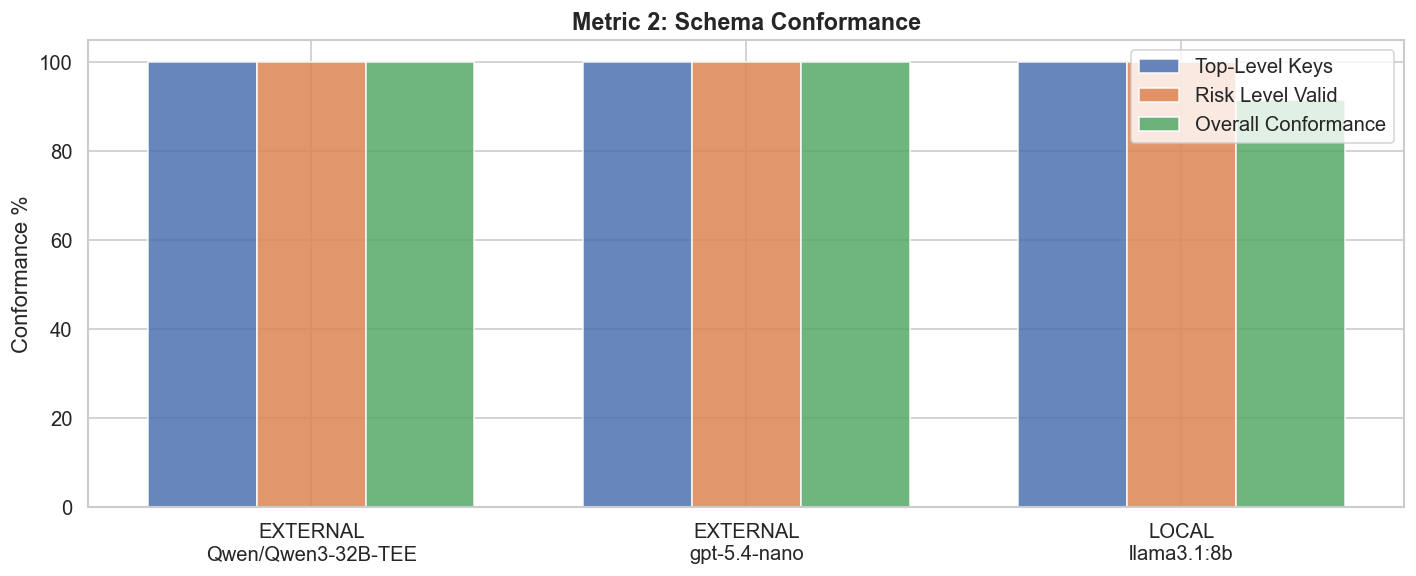

In [27]:
if len(schema_conf) > 0:
    labels = schema_conf["provider"] + "\n" + schema_conf["model"]
    x = np.arange(len(labels))
    width = 0.25

    fig, ax = plt.subplots(figsize=(12, 5))
    ax.bar(x - width, schema_conf["mean_top_level"], width, label="Top-Level Keys", alpha=0.85)
    ax.bar(x, schema_conf["risk_level_valid_pct"], width, label="Risk Level Valid", alpha=0.85)
    ax.bar(x + width, schema_conf["mean_overall"], width, label="Overall Conformance", alpha=0.85)
    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.set_ylabel("Conformance %")
    ax.set_ylim(0, 105)
    ax.set_title("Metric 2: Schema Conformance", fontsize=14, fontweight="bold")
    ax.legend()
    plt.tight_layout()
    plt.savefig("schema_conformance_rates.png", dpi=300)
    plt.show()

 ---
 ## 4. Finding Field Completeness

 For each finding the LLM generates, how many of the expected fields
 (`id`, `severity`, `category`, `title`, `description`, `evidence`,
 `compliance_impact`, `recommendation`, `priority`) are present?

In [28]:
def compute_finding_completeness(entries: List[Dict]) -> pd.DataFrame:
    """Compute per-finding field completeness from raw entries."""
    rows = []
    for e in entries:
        ic = e.get("insight_call") or {}
        sv = ic.get("schema_validation") or {}
        provider = e.get("provider", "UNKNOWN")
        model = e.get("model", "unknown")

        for fc in sv.get("findings_field_completeness", []):
            rows.append({
                "provider": provider,
                "model": model,
                "finding_index": fc["finding_index"],
                "completeness": fc["completeness"],
                "missing_fields": ", ".join(fc.get("missing", [])),
                "n_missing": len(fc.get("missing", [])),
            })
    return pd.DataFrame(rows)

finding_comp = compute_finding_completeness(raw_entries)
if len(finding_comp) > 0:
    summary = finding_comp.groupby(["provider", "model"]).agg(
        total_findings=("completeness", "count"),
        mean_completeness=("completeness", "mean"),
        median_completeness=("completeness", "median"),
        std_completeness=("completeness", "std"),
        fully_complete=("completeness", lambda x: (x == 1.0).sum()),
    ).reset_index()
    summary["pct_fully_complete"] = (summary["fully_complete"] / summary["total_findings"] * 100).round(1)
    print("=== Finding Field Completeness ===")
    display(summary)

    # Most commonly missing fields
    if len(finding_comp[finding_comp["n_missing"] > 0]) > 0:
        all_missing = []
        for ml in finding_comp["missing_fields"]:
            if ml:
                all_missing.extend(ml.split(", "))
        print("\nMost commonly missing fields:")
        for field, count in Counter(all_missing).most_common(10):
            print(f"  {field}: {count}")
else:
    print("No finding completeness data available.")

=== Finding Field Completeness ===


,provider,model,total_findings,mean_completeness,median_completeness,std_completeness,fully_complete,pct_fully_complete
0,EXTERNAL,Qwen/Qwen3-32B-TEE,105,1.0,1.0,0.0,105,100.0
1,EXTERNAL,gpt-5.4-nano,149,1.0,1.0,0.0,149,100.0
2,LOCAL,llama3.1:8b,95,1.0,1.0,0.0,95,100.0


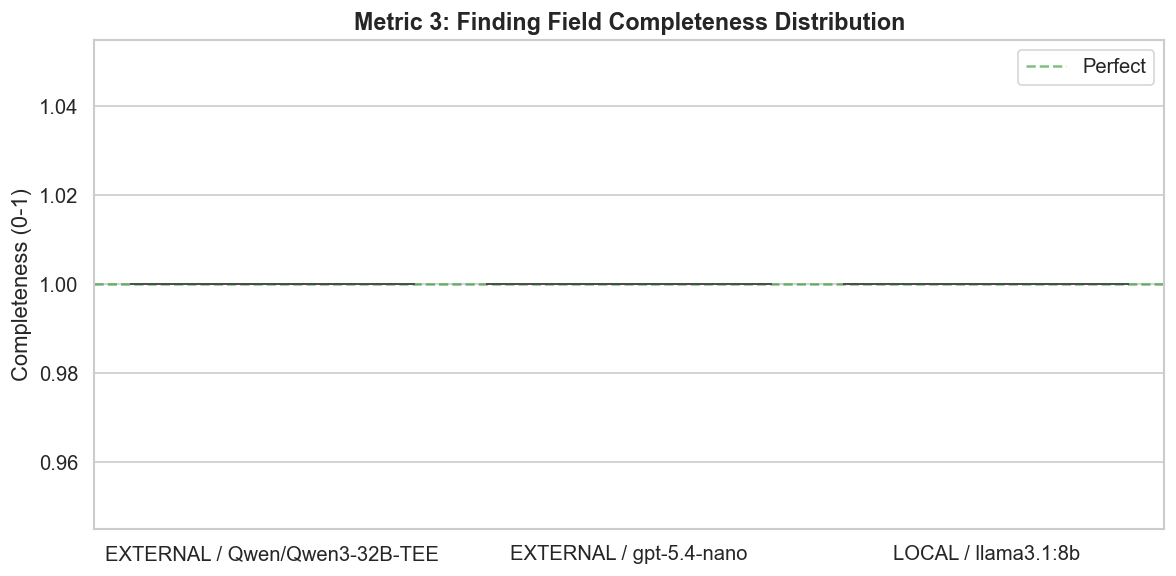

In [29]:
if len(finding_comp) > 0:
    fig, ax = plt.subplots(figsize=(10, 5))
    finding_comp["label"] = finding_comp["provider"] + " / " + finding_comp["model"]
    sns.boxplot(data=finding_comp, x="label", y="completeness", ax=ax, palette="deep")
    ax.set_title("Metric 3: Finding Field Completeness Distribution", fontsize=14, fontweight="bold")
    ax.set_ylabel("Completeness (0-1)")
    ax.set_xlabel("")
    ax.axhline(y=1.0, color="green", linestyle="--", alpha=0.5, label="Perfect")
    ax.legend()
    plt.tight_layout()
    plt.savefig("finding_field_completeness.png", dpi=300)
    plt.show()

 ---
 ## 5. Severity Distribution Validity

 Are the severity values the LLM assigns actually valid enum members?
 Valid: `critical`, `high`, `medium`, `low`, `info`.

In [30]:
def compute_severity_validity(entries: List[Dict]) -> pd.DataFrame:
    """Check if LLM-generated severity values are valid enum members."""
    rows = []
    for e in entries:
        ic = e.get("insight_call") or {}
        sv = ic.get("schema_validation") or {}
        provider = e.get("provider", "UNKNOWN")
        model = e.get("model", "unknown")

        for sev in sv.get("severity_validity", []):
            rows.append({
                "provider": provider,
                "model": model,
                "severity": sev["severity"],
                "valid": sev["valid"],
            })
    return pd.DataFrame(rows)

severity_df = compute_severity_validity(raw_entries)
if len(severity_df) > 0:
    sev_summary = severity_df.groupby(["provider", "model"]).agg(
        total=("valid", "count"),
        valid_count=("valid", "sum"),
    ).reset_index()
    sev_summary["validity_rate"] = (sev_summary["valid_count"] / sev_summary["total"] * 100).round(1)
    print("=== Severity Distribution Validity ===")
    display(sev_summary)

    # Distribution of severity values
    print("\nSeverity value distribution:")
    display(severity_df.groupby(["provider", "model", "severity"]).size().unstack(fill_value=0))
else:
    print("No severity data available.")

=== Severity Distribution Validity ===


,provider,model,total,valid_count,validity_rate
0,EXTERNAL,Qwen/Qwen3-32B-TEE,105,105,100.0
1,EXTERNAL,gpt-5.4-nano,149,149,100.0
2,LOCAL,llama3.1:8b,95,95,100.0



Severity value distribution:


severity                     critical  high  low  medium
provider model                                          
EXTERNAL Qwen/Qwen3-32B-TEE        40    50    0      15
         gpt-5.4-nano              60    57    1      31
LOCAL    llama3.1:8b               27    33    5      30

 ---
 ## 6. Latency Analysis

 Wall-clock time for each LLM call and the full pipeline.
 The pipeline makes **2 LLM calls**: compliance observations + insight generation.

In [31]:
def compute_latency_stats(df: pd.DataFrame) -> pd.DataFrame:
    """Compute latency statistics by provider/model."""
    metrics = {
        "Compliance Call (s)": "cc_latency",
        "Insight LLM Call (s)": "llm_latency",
        "Insight Total (s)": "ic_latency",
        "Full Pipeline (s)": "total_pipeline_seconds",
    }

    rows = []
    for label, col in metrics.items():
        for (prov, model), grp in df.groupby(["provider", "model"]):
            vals = grp[col].dropna()
            if len(vals) == 0:
                continue
            rows.append({
                "metric": label,
                "provider": prov,
                "model": model,
                "n": len(vals),
                "mean": round(vals.mean(), 2),
                "std": round(vals.std(), 2),
                "median": round(vals.median(), 2),
                "min": round(vals.min(), 2),
                "max": round(vals.max(), 2),
            })
    return pd.DataFrame(rows)

latency_stats = compute_latency_stats(df)
print("=== Latency Statistics ===")
display(latency_stats)

=== Latency Statistics ===


,metric,provider,model,n,mean,std,median,min,max
0,Compliance Call (s),EXTERNAL,Qwen/Qwen3-32B-TEE,35,23.43,5.75,22.37,15.64,39.07
1,Compliance Call (s),EXTERNAL,gpt-5.4-nano,35,2.77,0.36,2.76,2.25,3.91
2,Compliance Call (s),LOCAL,llama3.1:8b,35,17.67,5.37,17.15,8.73,37.62
3,Insight LLM Call (s),EXTERNAL,Qwen/Qwen3-32B-TEE,35,48.09,8.66,46.93,31.39,76.83
4,Insight LLM Call (s),EXTERNAL,gpt-5.4-nano,35,14.40,1.95,14.21,10.98,18.35
5,Insight LLM Call (s),LOCAL,llama3.1:8b,35,83.89,18.66,79.93,61.49,163.30
6,Insight Total (s),EXTERNAL,Qwen/Qwen3-32B-TEE,35,48.10,8.66,46.94,31.39,76.84
7,Insight Total (s),EXTERNAL,gpt-5.4-nano,35,14.41,1.95,14.22,10.99,18.36
8,Insight Total (s),LOCAL,llama3.1:8b,35,83.90,18.66,79.94,61.50,163.31
9,Full Pipeline (s),EXTERNAL,Qwen/Qwen3-32B-TEE,35,71.56,10.41,70.67,56.29,97.35


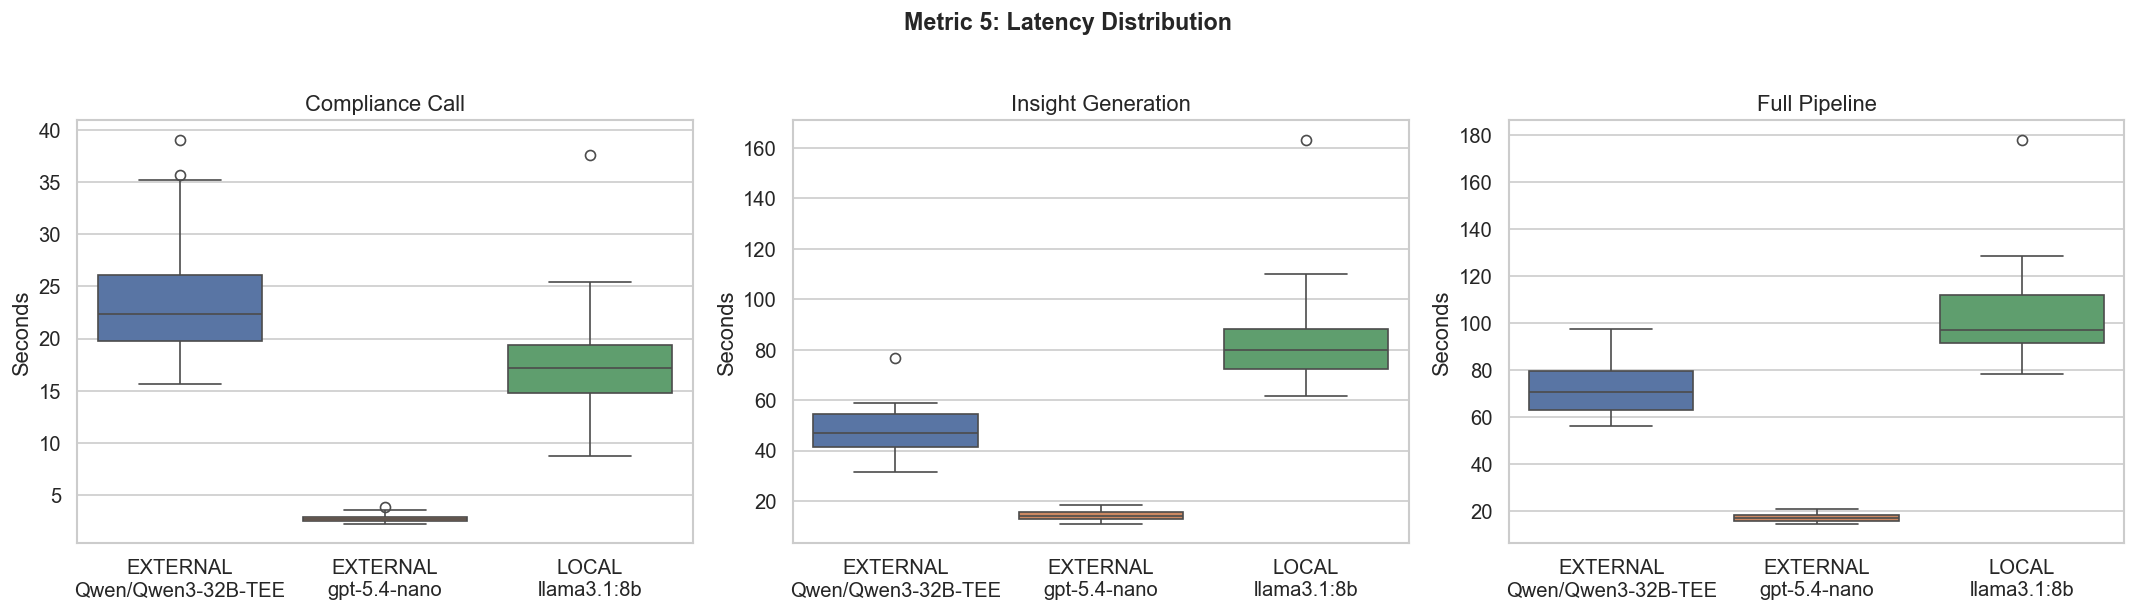

In [32]:
# Box plots for latency comparison
latency_cols = {"Compliance Call": "cc_latency", "Insight Generation": "ic_latency", "Full Pipeline": "total_pipeline_seconds"}
plot_df = df.copy()
plot_df["label"] = plot_df["provider"] + "\n" + plot_df["model"]

n_plots = sum(1 for c in latency_cols.values() if plot_df[c].notna().any())
if n_plots > 0:
    fig, axes = plt.subplots(1, n_plots, figsize=(6 * n_plots, 5))
    if n_plots == 1:
        axes = [axes]

    idx = 0
    for title, col in latency_cols.items():
        if plot_df[col].notna().any():
            sns.boxplot(data=plot_df, x="label", y=col, ax=axes[idx], palette="deep")
            axes[idx].set_title(title)
            axes[idx].set_ylabel("Seconds")
            axes[idx].set_xlabel("")
            idx += 1

    plt.suptitle("Metric 5: Latency Distribution", fontsize=14, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.savefig("latency_comparison.png", dpi=300)
    plt.show()

 ---
 ## 7. Token / Cost Estimation

 Estimated token usage based on character count (÷4 heuristic).
 Actual costs depend on provider pricing.

In [33]:
# Configurable cost rates ($ per 1K tokens)
COST_RATES = {
    # model_name: {"input": $/1K, "output": $/1K}
    "deepseek-ai/DeepSeek-V3-0324": {"input": 0.0005, "output": 0.0015},
    "gpt-4o": {"input": 0.005, "output": 0.015},
    "gpt-4o-mini": {"input": 0.00015, "output": 0.0006},
    "llama3.1:8b": {"input": 0.0, "output": 0.0},  # local
}

def compute_token_costs(df: pd.DataFrame) -> pd.DataFrame:
    """Estimate token usage and costs per run."""
    rows = []
    for _, row in df.iterrows():
        total_input = (row.get("cc_prompt_tokens") or 0) + (row.get("ic_prompt_tokens") or 0)
        total_output = (row.get("cc_response_tokens") or 0) + (row.get("ic_response_tokens") or 0)

        model = row.get("model", "")
        rates = COST_RATES.get(model, {"input": 0, "output": 0})
        cost = (total_input / 1000 * rates["input"]) + (total_output / 1000 * rates["output"])

        rows.append({
            "provider": row["provider"],
            "model": row["model"],
            "total_input_tokens": total_input,
            "total_output_tokens": total_output,
            "total_tokens": total_input + total_output,
            "estimated_cost_usd": round(cost, 6),
        })
    return pd.DataFrame(rows)

token_df = compute_token_costs(df)
if len(token_df) > 0:
    token_summary = token_df.groupby(["provider", "model"]).agg(
        runs=("total_tokens", "count"),
        mean_input_tokens=("total_input_tokens", "mean"),
        mean_output_tokens=("total_output_tokens", "mean"),
        mean_total_tokens=("total_tokens", "mean"),
        mean_cost_usd=("estimated_cost_usd", "mean"),
        total_cost_usd=("estimated_cost_usd", "sum"),
    ).reset_index().round(2)
    print("=== Token Usage & Cost Estimation ===")
    display(token_summary)

=== Token Usage & Cost Estimation ===


,provider,model,runs,mean_input_tokens,mean_output_tokens,mean_total_tokens,mean_cost_usd,total_cost_usd
0,EXTERNAL,Qwen/Qwen3-32B-TEE,35,2741.40,2332.09,5073.49,0.0,0.0
1,EXTERNAL,gpt-5.4-nano,35,2744.86,2472.89,5217.74,0.0,0.0
2,LOCAL,llama3.1:8b,35,2744.86,1048.57,3793.43,0.0,0.0


 ---
 ## 8. Cross-Run Consistency

 When running the same input multiple times, how consistent are the outputs?
 We measure variance in: finding count, severity distribution, and report length.

In [34]:
def compute_consistency(df: pd.DataFrame) -> pd.DataFrame:
    """Compute cross-run consistency metrics for same (provider, model, period) groups."""
    group_cols = ["provider", "model", "period"]
    value_cols = ["total_findings_count", "llm_findings_count", "report_length_chars"]

    rows = []
    for keys, grp in df.groupby(group_cols):
        if len(grp) < 2:
            continue  # Need multiple runs for consistency
        prov, model, period = keys
        row = {"provider": prov, "model": model, "period": period, "n_runs": len(grp)}

        for col in value_cols:
            vals = grp[col].dropna()
            if len(vals) >= 2:
                row[f"{col}_mean"] = round(vals.mean(), 2)
                row[f"{col}_std"] = round(vals.std(), 2)
                row[f"{col}_cv"] = round(vals.std() / vals.mean(), 3) if vals.mean() != 0 else None
            else:
                row[f"{col}_mean"] = vals.mean() if len(vals) > 0 else None
                row[f"{col}_std"] = None
                row[f"{col}_cv"] = None
        rows.append(row)

    return pd.DataFrame(rows)

consistency_df = compute_consistency(df)
if len(consistency_df) > 0:
    print("=== Cross-Run Consistency (groups with 2+ runs for same input) ===")
    display(consistency_df)

    # Aggregate CV by provider
    cv_cols = [c for c in consistency_df.columns if c.endswith("_cv")]
    if cv_cols:
        agg_cv = consistency_df.groupby(["provider", "model"])[cv_cols].mean().round(3)
        print("\nMean Coefficient of Variation (lower = more consistent):")
        display(agg_cv)
else:
    print("Need multiple runs per (provider, model, period) for consistency analysis.")
    print("Re-run the pipeline multiple times with the same inputs to populate this metric.")

=== Cross-Run Consistency (groups with 2+ runs for same input) ===


,provider,model,period,n_runs,total_findings_count_mean,total_findings_count_std,total_findings_count_cv,llm_findings_count_mean,llm_findings_count_std,llm_findings_count_cv,report_length_chars_mean,report_length_chars_std,report_length_chars_cv
0,EXTERNAL,Qwen/Qwen3-32B-TEE,2019-11-07T00:00:00 (window=90d),5,5.0,0.00,0.000,3.0,0.00,0.000,7840.2,527.01,0.067
1,EXTERNAL,Qwen/Qwen3-32B-TEE,2020-02-05T00:00:00 (window=90d),5,5.0,0.00,0.000,3.0,0.00,0.000,7637.0,545.34,0.071
2,EXTERNAL,Qwen/Qwen3-32B-TEE,2020-05-05T00:00:00 (window=90d),5,5.0,0.00,0.000,3.0,0.00,0.000,7925.0,627.87,0.079
3,EXTERNAL,Qwen/Qwen3-32B-TEE,2020-08-03T00:00:00 (window=90d),5,5.0,0.00,0.000,3.0,0.00,0.000,7331.6,570.05,0.078
4,EXTERNAL,Qwen/Qwen3-32B-TEE,2020-11-01T00:00:00 (window=90d),5,5.0,0.00,0.000,3.0,0.00,0.000,7233.0,376.84,0.052
5,EXTERNAL,Qwen/Qwen3-32B-TEE,2021-01-30T00:00:00 (window=90d),5,5.0,0.00,0.000,3.0,0.00,0.000,8117.6,1091.19,0.134
6,EXTERNAL,Qwen/Qwen3-32B-TEE,Unknown period,5,4.0,0.00,0.000,3.0,0.00,0.000,7209.0,761.96,0.106
7,EXTERNAL,gpt-5.4-nano,2019-11-07T00:00:00 (window=90d),5,6.2,0.45,0.072,4.2,0.45,0.106,10202.8,611.01,0.060
8,EXTERNAL,gpt-5.4-nano,2020-02-05T00:00:00 (window=90d),5,6.0,0.00,0.000,4.0,0.00,0.000,10042.2,266.59,0.027
9,EXTERNAL,gpt-5.4-nano,2020-05-05T00:00:00 (window=90d),5,6.2,0.45,0.072,4.2,0.45,0.106,10224.4,474.66,0.046



Mean Coefficient of Variation (lower = more consistent):


total_findings_count_cv  llm_findings_count_cv  \
provider model                                                                
EXTERNAL Qwen/Qwen3-32B-TEE                    0.000                  0.000   
         gpt-5.4-nano                          0.041                  0.061   
LOCAL    llama3.1:8b                           0.151                  0.247   

                             report_length_chars_cv  
provider model                                       
EXTERNAL Qwen/Qwen3-32B-TEE                   0.084  
         gpt-5.4-nano                         0.052  
LOCAL    llama3.1:8b                          0.147

 ---
 ## 9. Findings Origin: LLM vs Heuristic

 The insight agent adds heuristic-based findings to compensate for
 LLM gaps (e.g., MFA coverage, high failure rate thresholds).
 Fewer heuristic additions = better analytical LLM capability.

In [35]:
def compute_findings_origin(df: pd.DataFrame) -> pd.DataFrame:
    """Compute the split between LLM-originated and heuristic-injected findings."""
    group = df.groupby(["provider", "model"]).agg(
        total_runs=("run_id", "count"),
        mean_llm_findings=("llm_findings_count", "mean"),
        mean_heuristic_findings=("heuristic_findings_added", "mean"),
        mean_total_findings=("total_findings_count", "mean"),
    ).reset_index()

    group["llm_pct"] = (group["mean_llm_findings"] / group["mean_total_findings"] * 100).round(1)
    group["heuristic_pct"] = (100 - group["llm_pct"]).round(1)
    return group

findings_origin = compute_findings_origin(df)
if len(findings_origin) > 0:
    print("=== Findings Origin: LLM vs Heuristic ===")
    display(findings_origin[["provider", "model", "total_runs",
                              "mean_llm_findings", "mean_heuristic_findings",
                              "mean_total_findings", "llm_pct", "heuristic_pct"]])

=== Findings Origin: LLM vs Heuristic ===


,provider,model,total_runs,mean_llm_findings,mean_heuristic_findings,mean_total_findings,llm_pct,heuristic_pct
0,EXTERNAL,Qwen/Qwen3-32B-TEE,35,3.000000,1.857143,4.857143,61.8,38.2
1,EXTERNAL,gpt-5.4-nano,35,4.257143,1.857143,6.114286,69.6,30.4
2,LOCAL,llama3.1:8b,35,2.800000,1.857143,4.657143,60.1,39.9


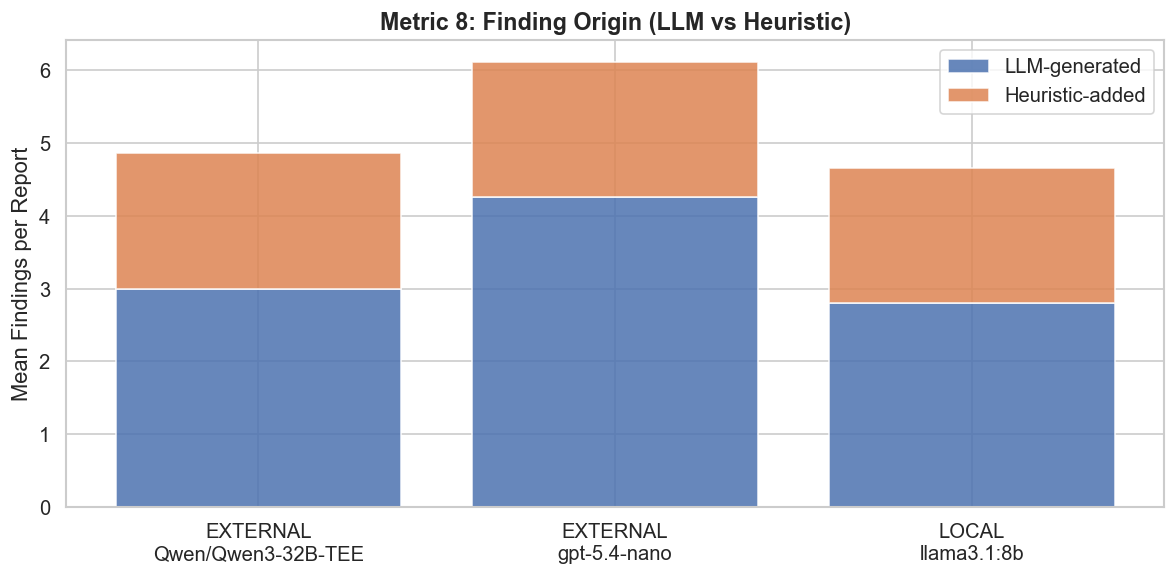

In [36]:
if len(findings_origin) > 0:
    labels = findings_origin["provider"] + "\n" + findings_origin["model"]
    x = np.arange(len(labels))

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.bar(x, findings_origin["mean_llm_findings"], label="LLM-generated", alpha=0.85)
    ax.bar(x, findings_origin["mean_heuristic_findings"],
           bottom=findings_origin["mean_llm_findings"], label="Heuristic-added", alpha=0.85)
    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.set_ylabel("Mean Findings per Report")
    ax.set_title("Metric 8: Finding Origin (LLM vs Heuristic)", fontsize=14, fontweight="bold")
    ax.legend()
    plt.tight_layout()
    plt.savefig("findings_origin.png", dpi=300)
    plt.show()

 ---
 ## 10. Response Length Distribution

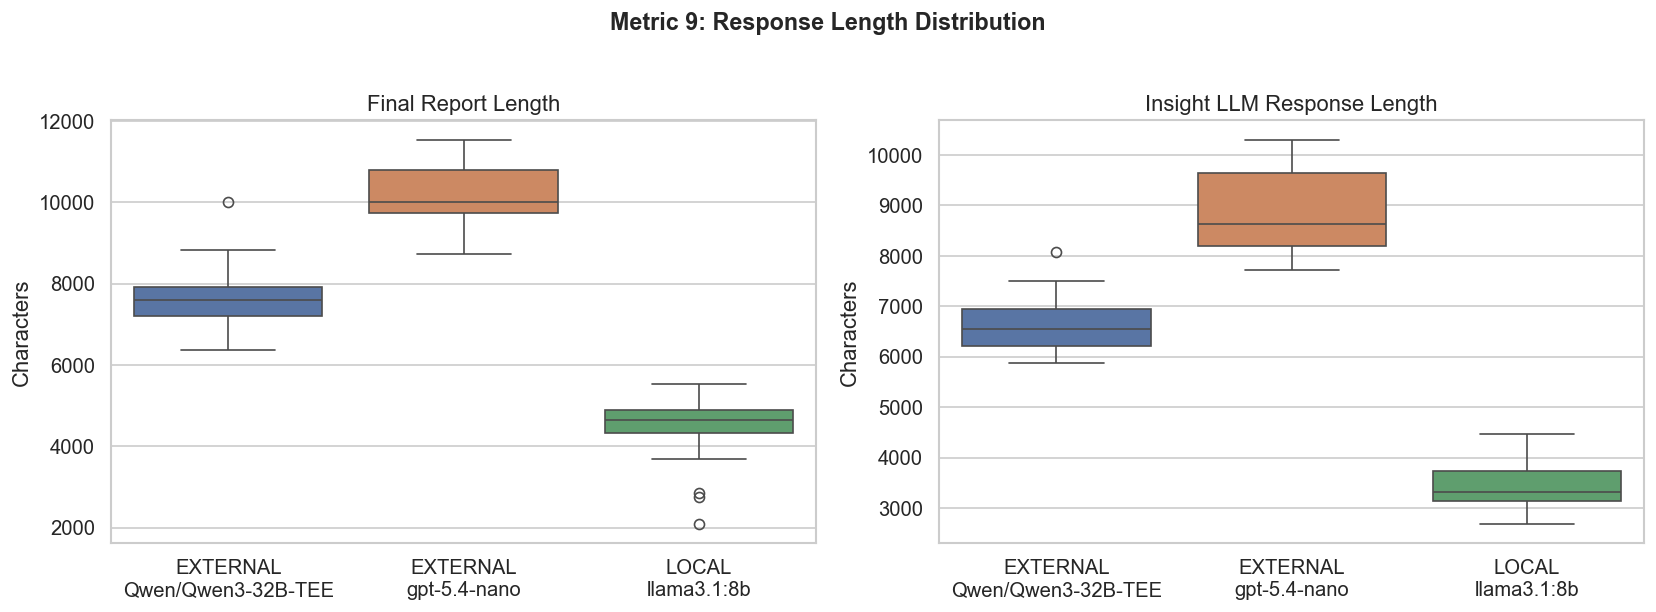

In [37]:
if df["report_length_chars"].notna().any():
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    plot_df = df.copy()
    plot_df["label"] = plot_df["provider"] + "\n" + plot_df["model"]

    sns.boxplot(data=plot_df, x="label", y="report_length_chars", ax=axes[0], palette="deep")
    axes[0].set_title("Final Report Length")
    axes[0].set_ylabel("Characters")
    axes[0].set_xlabel("")

    sns.boxplot(data=plot_df, x="label", y="ic_response_chars", ax=axes[1], palette="deep")
    axes[1].set_title("Insight LLM Response Length")
    axes[1].set_ylabel("Characters")
    axes[1].set_xlabel("")

    plt.suptitle("Metric 9: Response Length Distribution", fontsize=14, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.savefig("response_length_distribution.png", dpi=300)
    plt.show()

 ---
 ## 11. Statistical Comparison (Paired Tests)

 If you have runs from multiple providers on the **same** time windows,
 we perform paired statistical tests to check significance.

In [38]:
def run_statistical_tests(df: pd.DataFrame) -> pd.DataFrame:
    """Run paired statistical tests between providers for key metrics."""
    providers = df["provider"].unique()
    if len(providers) < 2:
        print(f"Only {len(providers)} provider(s) found. Need 2+ for statistical comparison.")
        return pd.DataFrame()

    test_metrics = {
        "ic_latency": "Insight Latency (s)",
        "total_pipeline_seconds": "Pipeline Latency (s)",
        "schema_overall_conformance": "Schema Conformance",
        "total_findings_count": "Total Findings",
        "llm_findings_count": "LLM Findings",
        "report_length_chars": "Report Length",
    }

    results = []
    # Compare all pairs of providers
    for i, p1 in enumerate(providers):
        for p2 in providers[i + 1:]:
            for col, label in test_metrics.items():
                v1 = df[df["provider"] == p1][col].dropna().values
                v2 = df[df["provider"] == p2][col].dropna().values

                if len(v1) < 3 or len(v2) < 3:
                    continue

                # Mann-Whitney U test (non-parametric, doesn't assume normality)
                try:
                    stat, pval = stats.mannwhitneyu(v1, v2, alternative="two-sided")
                except ValueError:
                    continue

                # Cohen's d effect size
                pooled_std = np.sqrt(((len(v1)-1)*np.std(v1, ddof=1)**2 +
                                      (len(v2)-1)*np.std(v2, ddof=1)**2) /
                                     (len(v1) + len(v2) - 2))
                cohens_d = (np.mean(v1) - np.mean(v2)) / pooled_std if pooled_std > 0 else 0

                results.append({
                    "metric": label,
                    f"{p1}_mean": round(np.mean(v1), 3),
                    f"{p1}_std": round(np.std(v1, ddof=1), 3),
                    f"{p2}_mean": round(np.mean(v2), 3),
                    f"{p2}_std": round(np.std(v2, ddof=1), 3),
                    "p_value": round(pval, 4),
                    "significant": "Yes" if pval < 0.05 else "No",
                    "cohens_d": round(cohens_d, 3),
                    "effect_size": (
                        "Large" if abs(cohens_d) > 0.8 else
                        "Medium" if abs(cohens_d) > 0.5 else
                        "Small" if abs(cohens_d) > 0.2 else "Negligible"
                    ),
                })

    return pd.DataFrame(results)

stat_tests = run_statistical_tests(df)
if len(stat_tests) > 0:
    print("=== Statistical Tests (Mann-Whitney U) ===")
    display(stat_tests)
else:
    print("Insufficient data for statistical tests.")

=== Statistical Tests (Mann-Whitney U) ===


,metric,EXTERNAL_mean,EXTERNAL_std,LOCAL_mean,LOCAL_std,p_value,significant,cohens_d,effect_size
0,Insight Latency (s),31.251,18.075,83.897,18.664,0.0000,Yes,-2.881,Large
1,Pipeline Latency (s),44.389,28.358,101.610,18.961,0.0000,Yes,-2.232,Large
2,Schema Conformance,1.000,0.000,0.914,0.284,0.0138,Yes,0.525,Medium
3,Total Findings,5.486,0.812,4.657,0.838,0.0000,Yes,1.010,Large
4,LLM Findings,3.629,0.705,2.800,0.719,0.0000,Yes,1.167,Large
5,Report Length,8901.871,1486.743,4513.200,754.233,0.0000,Yes,3.398,Large


 ---
 ## 12. Summary Comparison Table

 One-table overview of all automated metrics for each provider/model.

In [39]:
def build_summary_table(df: pd.DataFrame, entries: List[Dict]) -> pd.DataFrame:
    """Build the final comparison table combining all metrics."""
    rows = []
    for (prov, model), grp in df.groupby(["provider", "model"]):
        n = len(grp)
        row = {
            "Provider": prov,
            "Model": model,
            "Runs": n,
        }

        # JSON Parse
        row["JSON Parse Rate (%)"] = round(grp["json_parse_success"].mean() * 100, 1) if grp["json_parse_success"].notna().any() else None

        # Schema Conformance
        row["Schema Conformance (%)"] = round(grp["schema_overall_conformance"].mean() * 100, 1) if grp["schema_overall_conformance"].notna().any() else None

        # Severity validity
        sev_df = compute_severity_validity([e for e in entries if e.get("provider") == prov and e.get("model") == model])
        if len(sev_df) > 0:
            row["Severity Valid (%)"] = round(sev_df["valid"].mean() * 100, 1)
        else:
            row["Severity Valid (%)"] = None

        # Latency
        row["Mean Latency (s)"] = round(grp["total_pipeline_seconds"].mean(), 1) if grp["total_pipeline_seconds"].notna().any() else None

        # Findings
        row["Mean LLM Findings"] = round(grp["llm_findings_count"].mean(), 1) if grp["llm_findings_count"].notna().any() else None
        row["Mean Heuristic Findings"] = round(grp["heuristic_findings_added"].mean(), 1) if grp["heuristic_findings_added"].notna().any() else None

        # Token estimation
        total_tokens = (grp["cc_prompt_tokens"].fillna(0) + grp["cc_response_tokens"].fillna(0) +
                        grp["ic_prompt_tokens"].fillna(0) + grp["ic_response_tokens"].fillna(0))
        row["Mean Tokens/Run"] = round(total_tokens.mean(), 0) if total_tokens.notna().any() else None

        # Report length
        row["Mean Report Len"] = round(grp["report_length_chars"].mean(), 0) if grp["report_length_chars"].notna().any() else None

        rows.append(row)

    return pd.DataFrame(rows)

summary = build_summary_table(df, raw_entries)
print("=" * 80)
print("FINAL COMPARISON TABLE")
print("=" * 80)
display(summary.T)  # Transpose for readability

FINAL COMPARISON TABLE


,0,1,2
Provider,EXTERNAL,EXTERNAL,LOCAL
Model,Qwen/Qwen3-32B-TEE,gpt-5.4-nano,llama3.1:8b
Runs,35,35,35
JSON Parse Rate (%),100.0,100.0,91.4
Schema Conformance (%),100.0,100.0,91.4
Severity Valid (%),100.0,100.0,100.0
Mean Latency (s),71.6,17.2,101.6
Mean LLM Findings,3.0,4.3,2.8
Mean Heuristic Findings,1.9,1.9,1.9
Mean Tokens/Run,5073.0,5218.0,3793.0


 ---
 ## 13. Export Results

 Save all computed metrics to CSV/JSON for inclusion in the research paper.

In [40]:
OUTPUT_DIR = Path("../out/eval_results")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Save summary table
summary.to_csv(OUTPUT_DIR / "summary_comparison.csv", index=False)

# Save detailed metrics
if len(latency_stats) > 0:
    latency_stats.to_csv(OUTPUT_DIR / "latency_stats.csv", index=False)
if len(json_rates) > 0:
    json_rates.to_csv(OUTPUT_DIR / "json_parse_rates.csv", index=False)
if len(stat_tests) > 0:
    stat_tests.to_csv(OUTPUT_DIR / "statistical_tests.csv", index=False)
if len(finding_comp) > 0:
    finding_comp.to_csv(OUTPUT_DIR / "finding_completeness.csv", index=False)

# Save full flat data
df.to_csv(OUTPUT_DIR / "full_eval_data.csv", index=False)

print(f"Results exported to: {OUTPUT_DIR.resolve()}")
print(f"Files: {[f.name for f in OUTPUT_DIR.glob('*')]}")

Results exported to: D:\User Files\ProgFiles\python\cybersec-compliance\out\eval_results
Files: ['.pipeline_checkpoint.json', 'finding_completeness.csv', 'full_eval_data.csv', 'json_parse_rates.csv', 'latency_stats.csv', 'statistical_tests.csv', 'summary_comparison.csv']
